**1. Problem defination**

Applying linear regression.To find the relationship between electrical measurements and total power consumption in a household. The target variable selected for prediction is **Global_active_power**, as it represents the total active power consumed at a given time and directly reflects energy usage behavior. The input features chosen for this model include **Voltage, Global_intensity**, and the three sub-metering variables (**Sub_metering_1, Sub_metering_2, Sub_metering_3**), which correspond to energy consumption in specific areas such as kitchen, laundry, and heating systems.

**2. Data Collection & Importing**

Data is colleted from kaggle consists of 799073 columns and 9 rows in a text format(separated by semicolon)

In [173]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [174]:
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    low_memory=False, # Reads entire file at once... if True reads file in chunks
    na_values=["?"],
    parse_dates={"Datetime": ["Date", "Time"]},
    infer_datetime_format=True#this line automatically finds date format inside text
)
# It reads the raw text and converts it into a structured table(DataFrame)

/tmp/ipykernel_1547/172076897.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
/tmp/ipykernel_1547/172076897.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(
/tmp/ipykernel_1547/172076897.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


In [175]:
df.head()

,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [176]:
  df.shape

(2075259, 8)

**3. Data Preprocessing & EDA (Exploratory Data Analysis)**


In [177]:
df.info() #Data is in object format(mixed)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Datetime               datetime64[ns]
 1   Global_active_power    float64       
 2   Global_reactive_power  float64       
 3   Voltage                float64       
 4   Global_intensity       float64       
 5   Sub_metering_1         float64       
 6   Sub_metering_2         float64       
 7   Sub_metering_3         float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 126.7 MB


In [180]:
cols = ['Global_active_power', 'Global_reactive_power', 'Voltage',
        'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Datetime               datetime64[ns]
 1   Global_active_power    float64       
 2   Global_reactive_power  float64       
 3   Voltage                float64       
 4   Global_intensity       float64       
 5   Sub_metering_1         float64       
 6   Sub_metering_2         float64       
 7   Sub_metering_3         float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 126.7 MB


In [182]:
df.head() #Data converted into appropriate format

,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [183]:
# Feature Engineering: extracting important features from existing data(column).
df.set_index('Datetime', inplace=True)
df['hour'] = df.index.hour
df['day'] = df.index.day
df['month'] = df.index.month
df['weekday'] = df.index.weekday

In [184]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 11 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
 7   hour                   int32  
 8   day                    int32  
 9   month                  int32  
 10  weekday                int32  
dtypes: float64(7), int32(4)
memory usage: 158.3 MB


In [185]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day,month,weekday
Datetime,,,,,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,17,16,12,5
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,17,16,12,5
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,17,16,12,5
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,17,16,12,5
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,17,16,12,5


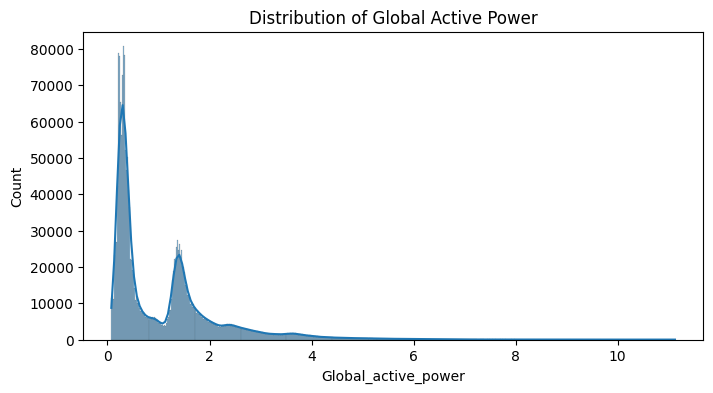

In [186]:
# Understanding the distribution of the data... it is like skewness analysis
plt.figure(figsize=(8,4))
sns.histplot(df['Global_active_power'], kde=True)
plt.title('Distribution of Global Active Power')
plt.show()

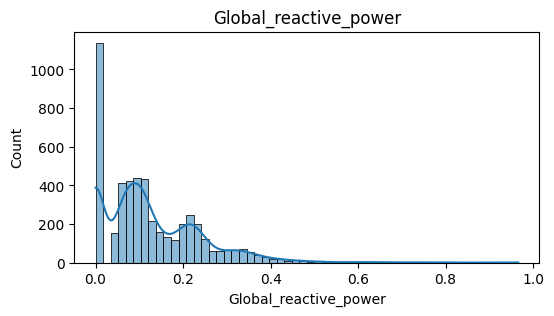

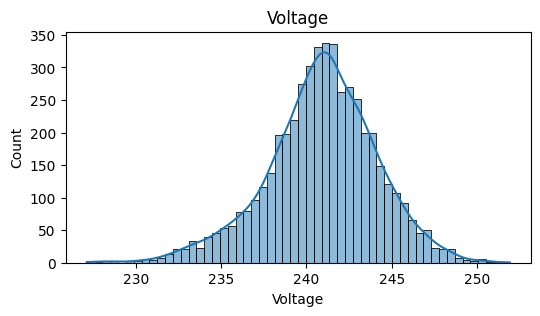

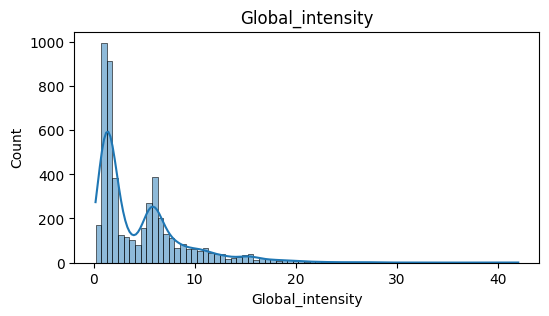

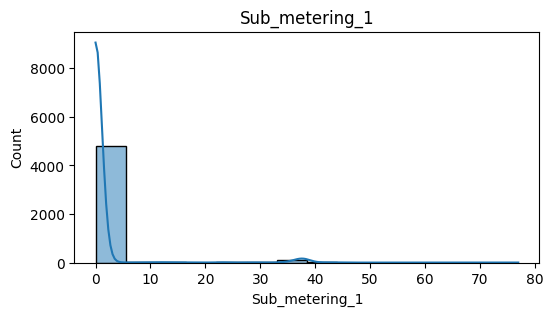

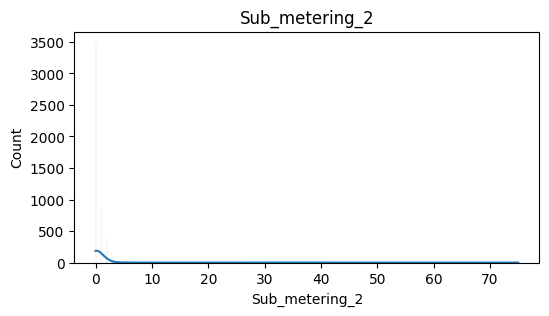

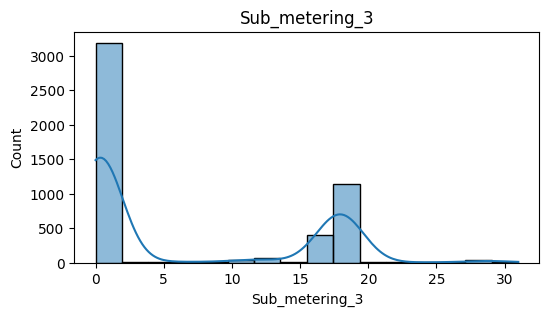

In [187]:
cols = ['Global_reactive_power', 'Voltage',
        'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

for col in cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col].sample(5000), kde=True)
    plt.title(col)
    plt.show()

**Insight from previous data distribution graphs **

* Most features (power, intensity, sub-metering) are heavily right-skewed,


* Voltage is stable and normally distributed

* Sub-metering features are sparse (many zeros), meaning certain appliances are used infrequently.


In [188]:
df.isnull().sum()

,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979
hour,0
day,0
month,0


In [189]:
df = df.dropna() # Deleting the missing rows is better because the dataset is too large
                  # removing 25979 rows is nregligible

In [190]:
df.isnull().sum()

,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0
hour,0
day,0
month,0


In [191]:
# Checking duplicates
df.duplicated().sum()

np.int64(10546)

In [192]:
df = df.drop_duplicates()

In [193]:
df.duplicated().sum()

np.int64(0)

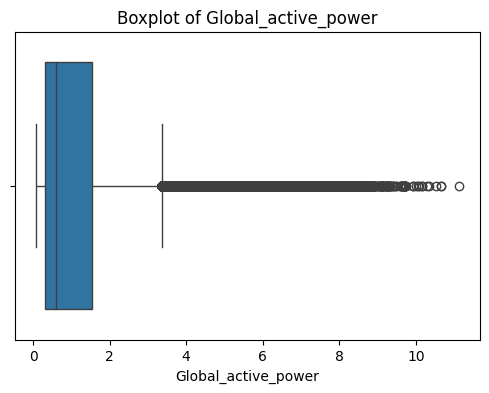

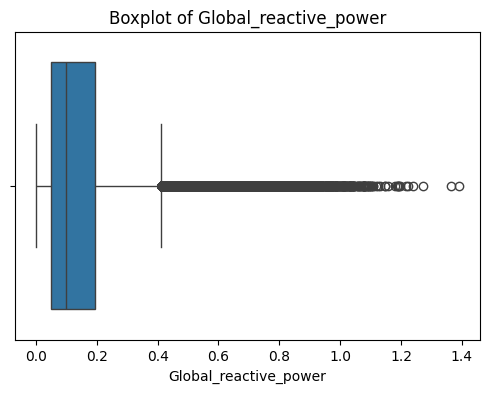

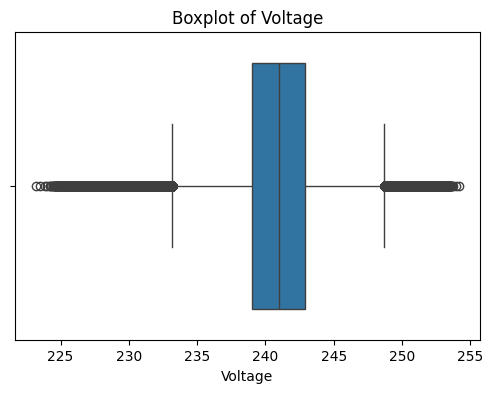

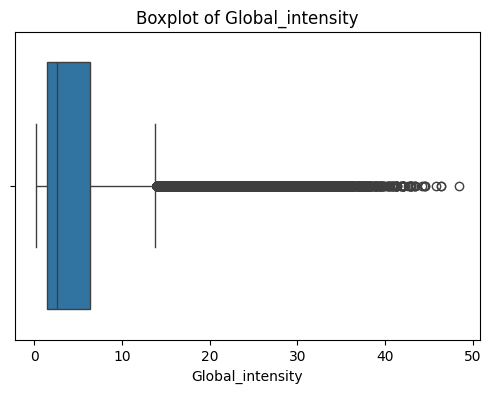

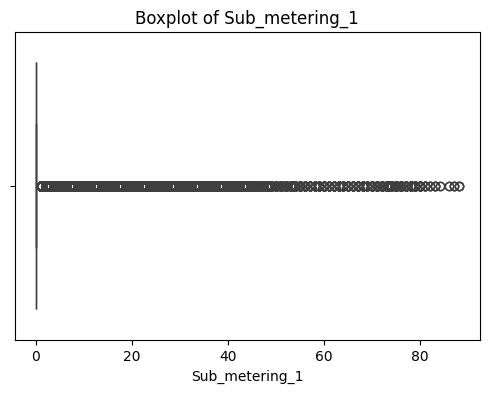

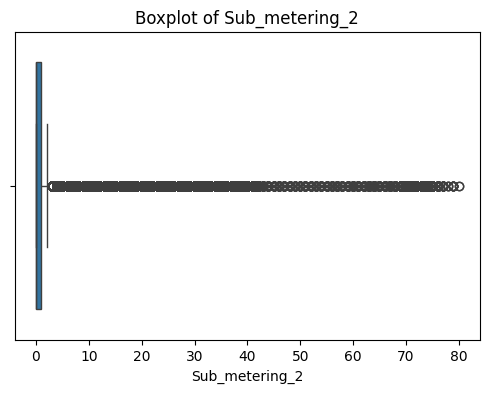

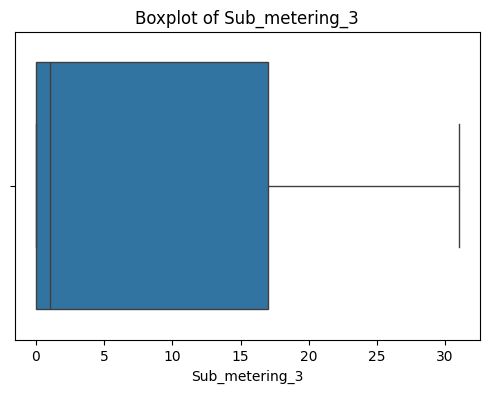

In [194]:
# Handling outliers

cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

for col in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Outlier analysis states that most numerical features are right-skewed distributions with several high-value observations. These outliers are not considered noise, as they represent genuine high energy consumption events such as peak appliance usage. Therefore, instead of removing these values, they were retained to preserve the real-world characteristics of the dataset.

In [195]:
corr_matrix = df.select_dtypes(include=['number']).corr()

<Axes: >

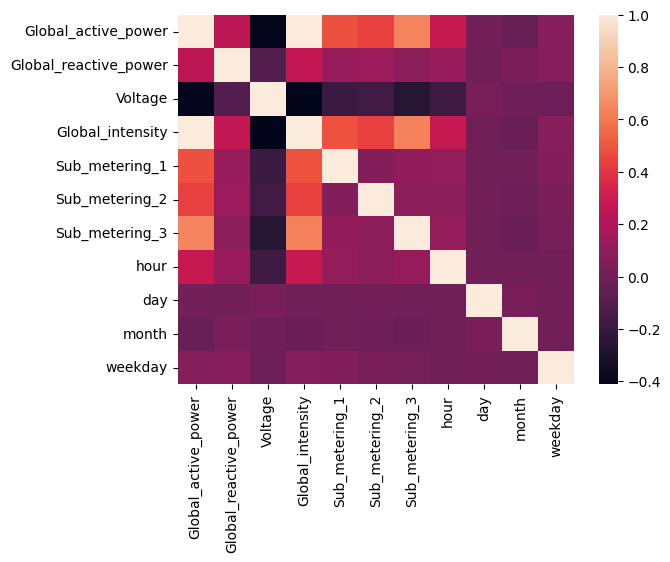

In [196]:

sns.heatmap(corr_matrix)

In [197]:
# Based on the correlation map plotted above input features are selected
X = df[[
    "Global_intensity",
    "Sub_metering_3",
    "Sub_metering_1",
    "Sub_metering_2",
    "Voltage",
    "Global_reactive_power"
]]

y = df["Global_active_power"]

**4. Data Splitting**

Distributing the data to test and train sets

In [198]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**5. Feature Scaling**

Not required because there is nomuch difference between the data values

**6. Model Training**

Training the model using LinearRegression

In [199]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [200]:
# y_pred = model.predict(X_test_scaled)

**7. Model Evaluation**

evaluating the metrics to test performance

In [216]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# mse = mean_square_error(y_test, y_pred)

# print("MSE", mse)
print("MAE:", mae)
print("R2 Score:", r2)

MAE: 0.004117749486814128
R2 Score: 0.9831435690880068


**8. Pickling the file**

In [202]:
import pickle

with open("linear_regression_model.pkl", "wb") as f:
    pickle.dump(model, f)

**=========================================================================**

**Logistic regression**

In [203]:
# Logistic Regression

In [204]:
df['Global_active_power'].mean()

np.float64(1.0950313459234995)

In [205]:
threshold = df["Global_active_power"].mean()

df["usage_type"] = df["Global_active_power"].apply(
    lambda x: 1 if x > threshold else 0
)

In [206]:
df['usage_type'].head()

,usage_type
Datetime,
2006-12-16 17:24:00,1
2006-12-16 17:25:00,1
2006-12-16 17:26:00,1
2006-12-16 17:27:00,1
2006-12-16 17:28:00,1


In [207]:
X = df[[
    "Global_intensity",
    "Sub_metering_3",
    "Sub_metering_1",
    "Sub_metering_2",
    "Voltage",
    "Global_reactive_power"
]]

y_class = df["usage_type"]

In [208]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_class,
    test_size=0.2,
    random_state=42
)

In [209]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [210]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

print(classification_report(y_test, y_pred))

Accuracy: 0.9958822505131859
[[233858    844]
 [   835 172210]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    234702
           1       1.00      1.00      1.00    173045

    accuracy                           1.00    407747
   macro avg       1.00      1.00      1.00    407747
weighted avg       1.00      1.00      1.00    407747



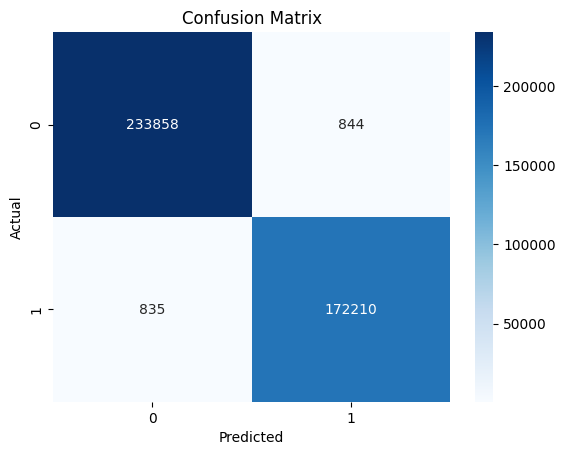

In [211]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [212]:
df["usage_type"].value_counts() #checking the class imbalance

,count
usage_type,
0,1173469
1,865265


In [213]:
import pickle

with open("logistic_model.pkl", "wb") as f:
    pickle.dump(clf, f)